In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.dates as mdates


%run src/donnees.py

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

In [171]:
df_final

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,id_usager,catu,grav,sexe,trajet,secu1,secu2,secu3,age,date
0,202400000001,25,3,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23,2024-03-25
1,202400000001,25,3,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29,2024-03-25
2,202400000002,20,3,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99,2024-03-20
3,202400000002,20,3,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 580,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39,2024-03-20
4,202400000002,20,3,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99,2024-03-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452971,202200055301,1,1,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,968 230,Conducteur,Indemne,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,24,2022-01-01
452972,202200055301,1,1,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,968 231,Passager,Blessé hospitalisé,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,22,2022-01-01
452973,202200055301,1,1,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,968 232,Conducteur,Blessé léger,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,73,2022-01-01
452974,202200055302,1,3,2022,16:55,Plein jour,41,41018,En agglomération,Hors intersection,...,968 228,Conducteur,Blessé hospitalisé,Homme,Domicile - Travail,Casque,Gants (2RM/3RM),Non renseigné,34,2022-03-01


## Fonctions

In [199]:
def nb_accidents_par(variable, nom_variable, afficher_nb=False):
    nb_accidents_groupe = df_final.groupby(variable).count().reset_index()
    
    bars = plt.bar(nb_accidents_groupe[variable], nb_accidents_groupe["Num_Acc"])
    
    # Annotation sur chaque barre
    if afficher_nb:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height):,}",
                ha="center", va="bottom",
                fontsize=9
            )
    
    plt.grid(which="both", axis="y")
    plt.xticks(nb_accidents_groupe[variable])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(nom_variable)
    plt.ylabel("Accidents")
    plt.title(f"Nombre d'accidents selon leur {nom_variable.lower()}")
    plt.show()


ordre_colonnes = [
    "Indemne", 
    "Blessé léger", 
    "Blessé hospitalisé", 
    "Tué"
]


def bar_chart(tc, label, titre):

    n = len(tc.columns)
    colors = [cm.magma(i / (n - 1)) for i in range(n)][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))

    tc.plot(kind="bar", stacked=True, ax=ax, color=colors)

    # Ajout des proportions sur chaque segment
    for bar_stack in ax.containers:
        for bar in bar_stack:
            height = bar.get_height()
            if height > 0.03:  # seuil pour éviter les labels illisibles
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.1%}",
                    ha="center", va="center",
                    fontsize=8, color="black"
                )

    plt.xlabel(label)
    plt.ylabel("Gravité")
    plt.title(titre)
    plt.legend(title="Gravité", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Visualisation des données

In [173]:
df_final.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,id_usager,catu,grav,sexe,trajet,secu1,secu2,secu3,age,date
0,202400000001,25,3,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23,2024-03-25
1,202400000001,25,3,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29,2024-03-25
2,202400000002,20,3,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99,2024-03-20


In [174]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452976 entries, 0 to 452975
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Num_Acc      452976 non-null  Int64         
 1   jour         452976 non-null  int64         
 2   mois         452976 non-null  int64         
 3   an           452976 non-null  int64         
 4   hrmn         452976 non-null  object        
 5   lum          452969 non-null  object        
 6   dep          452976 non-null  object        
 7   com          452976 non-null  object        
 8   agg          452976 non-null  object        
 9   int          452947 non-null  object        
 10  atm          452976 non-null  object        
 11  col          452976 non-null  object        
 12  adr          438983 non-null  object        
 13  lat          452976 non-null  object        
 14  long         452976 non-null  object        
 15  catr         452976 non-null  obje

In [175]:
df_final["hr"] = df_final["hrmn"].str[0:2]
df_final["hr"]

0         07
1         07
2         15
3         15
4         15
          ..
452971    08
452972    08
452973    08
452974    16
452975    16
Name: hr, Length: 452976, dtype: object

`describe` nous renseigne sur la distribution des variables numériques :

In [176]:
df_final.describe()

,Num_Acc,jour,mois,an,v1,situ,vma,age,date
count,452976.0,452976.000000,452976.000000,452976.000000,452976.000000,452976.000000,452976.000000,443048.0,452976
mean,202307956766.712158,15.552389,6.646957,2023.079293,-0.212062,1.526812,56.398487,41.721087,2023-08-03 17:43:31.401928448
min,202200000001.0,1.000000,1.000000,2022.000000,-1.000000,-1.000000,-1.000000,2.0,2022-01-01 00:00:00
25%,202200049458.0,8.000000,4.000000,2022.000000,0.000000,1.000000,50.000000,26.0,2022-11-20 00:00:00
50%,202300033451.0,15.000000,7.000000,2023.000000,0.000000,1.000000,50.000000,38.0,2023-08-19 00:00:00
75%,202400016534.0,23.000000,10.000000,2024.000000,0.000000,1.000000,80.000000,55.0,2024-04-27 00:00:00
max,202400054402.0,31.000000,12.000000,2024.000000,3.000000,8.000000,900.000000,113.0,2024-12-31 00:00:00
std,79514021.019897,8.738000,3.353770,0.795142,0.421107,1.533759,27.150398,19.153206,NaN


## Évolution du nombre d'accidents dans le temps

### Évolution globale

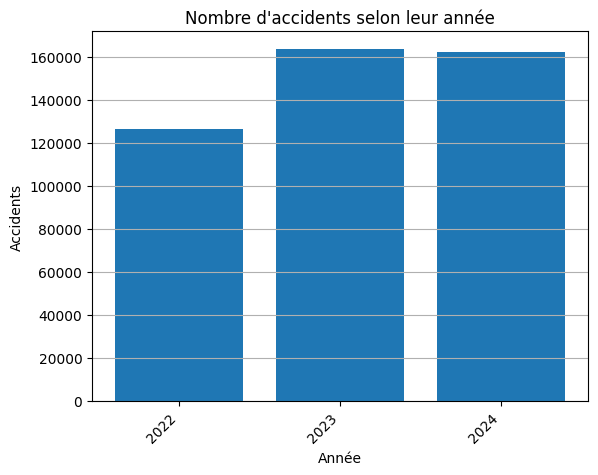

In [200]:
nb_accidents_par("an", "Année")

L'année 2022 est marquée par la sortie finale de confinement. Peut-on considérer que les accidents étaient encore affectés par les restrictions de circulation ?

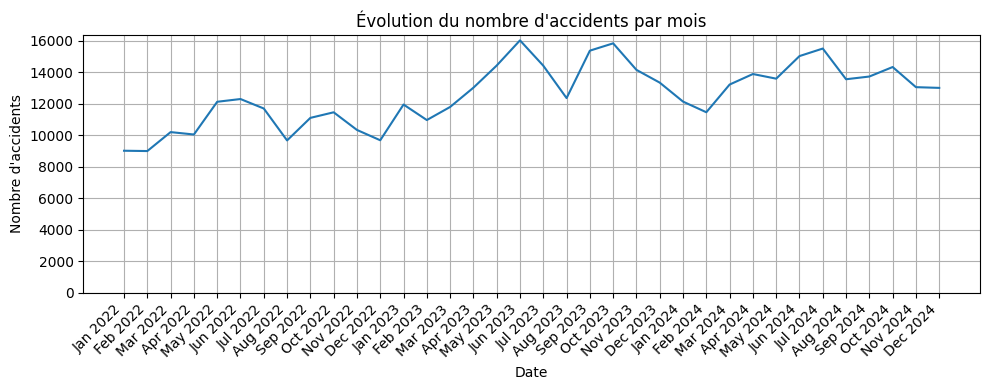

In [178]:

df_final["date"] = pd.to_datetime(df_final[["an", "mois", "jour"]].rename(columns={
    "an": "year",
    "mois": "month",
    "jour": "day"
}))

# Compte par mois
accidents_par_mois = df_final.groupby(df_final["date"].dt.to_period("M")).size().reset_index(name="Nombre d'accidents") 
accidents_par_mois["date"] = accidents_par_mois["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(len(accidents_par_mois)), accidents_par_mois["Nombre d'accidents"])

labels = accidents_par_mois["date"].dt.strftime("%b %Y")

ax.set_xticks(range(len(accidents_par_mois)))
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_ylim(bottom=0)
ax.set_title("Évolution du nombre d'accidents par mois")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'accidents")
plt.grid(which="both", axis="x")
plt.grid(which="both", axis="y")
plt.tight_layout()
plt.show()

On observe une légère tendance à la hausse, malgré des variations assez importantes selon les périodes.

### Évolution horaire

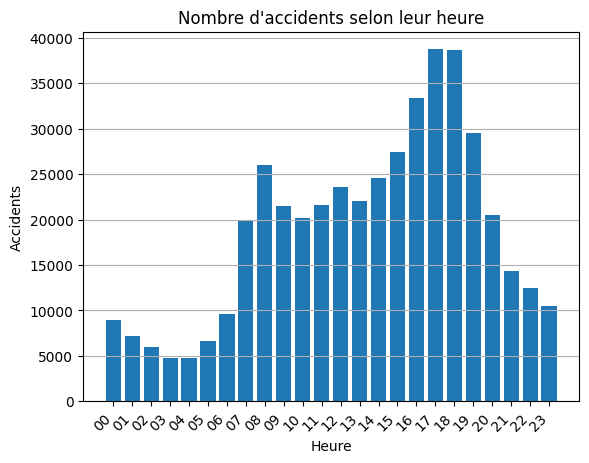

In [201]:
nb_accidents_par("hr", "Heure")

On observe deux modes aux heures de pointes, à 8 et 17 heures. Les accidents sont ensuite plus nombreux de jour que de nuit, et on peut supposer que leur nombre reflète globalement le trafic.

## Nombre et gravité des accidents selon les facteurs extérieurs

### Tests

In [180]:
def test_chi2(variable1, variable2):
    tc = pd.crosstab(df_final[variable1], df_final[variable2])
    chi2, p_value, dof, expected = chi2_contingency(tc)
    print(f"Chi² = {chi2:.2f}")
    print(f"p-value = {p_value:.4f}")
    print(f"Degrés de liberté = {dof}")

In [181]:
chi2_contingency(tc_atm_grav)

Chi2ContingencyResult(statistic=np.float64(2.0920811885096238), pvalue=np.float64(0.9999999999699046), dof=27, expected_freq=array([[0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871]]))

### Conditions routières


#### Catégorie de route

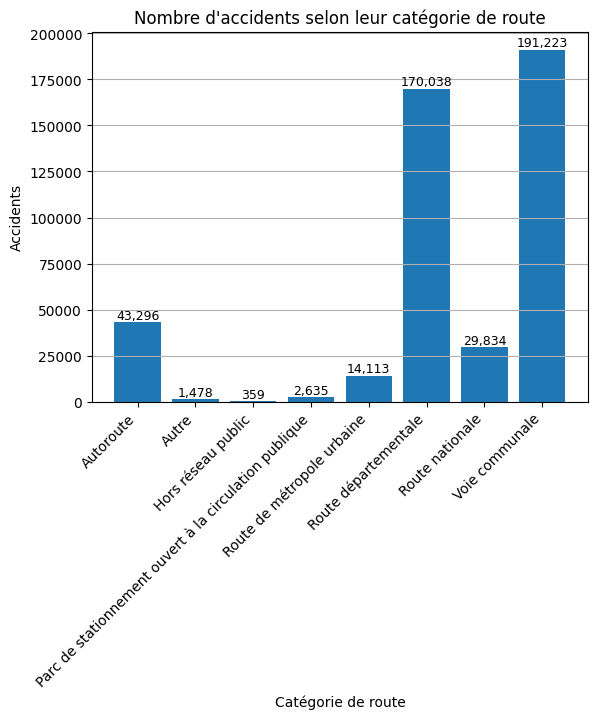

In [202]:
nb_accidents_par("catr", "Catégorie de route", True)

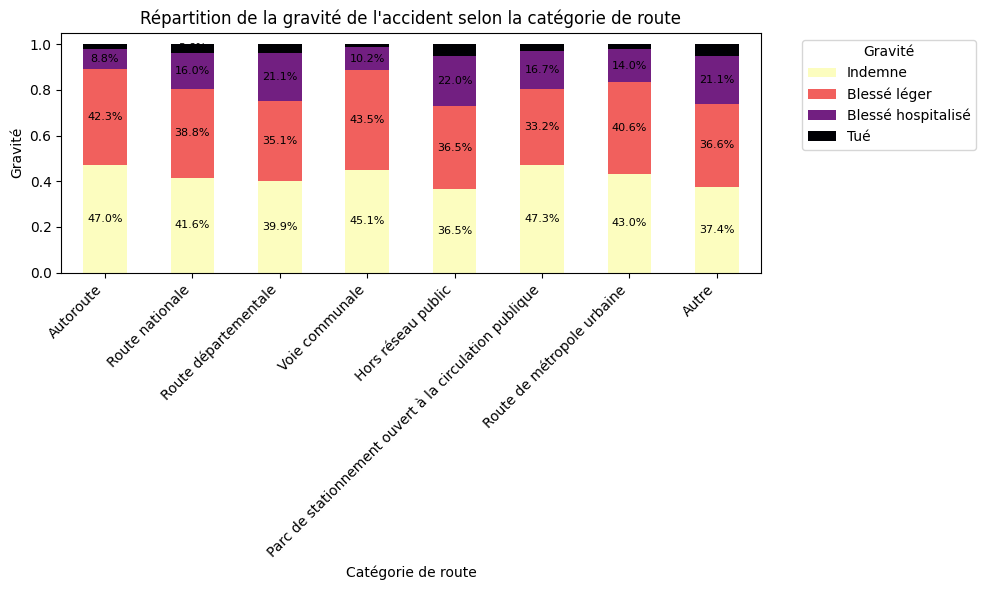

In [203]:
ordre_lignes = [
    "Autoroute",
    "Route nationale",
    "Route départementale",
    "Voie communale",
    "Hors réseau public",
    "Parc de stationnement ouvert à la circulation publique",
    "Route de métropole urbaine",
    "Autre"
]

tc_catr_grav = pd.crosstab(df_final["catr"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)
bar_chart(tc_catr_grav, "Catégorie de route", "Répartition de la gravité de l'accident selon la catégorie de route")

#### Type de collision

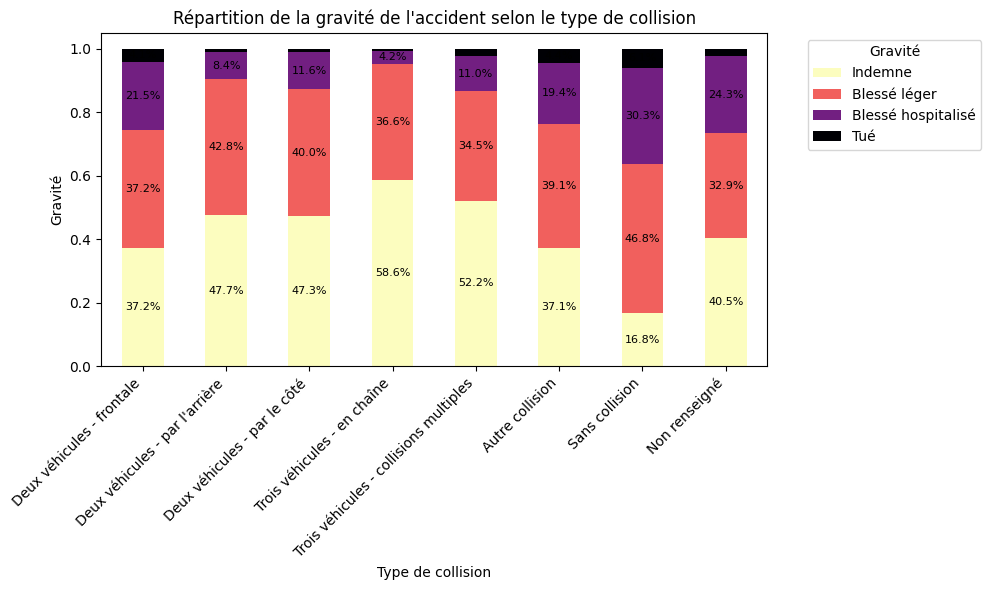

In [184]:
ordre_lignes = [
    "Deux véhicules - frontale",
    "Deux véhicules - par l'arrière",
    "Deux véhicules - par le côté",
    "Trois véhicules - en chaîne",
    "Trois véhicules - collisions multiples",
    "Autre collision",
    "Sans collision",
    "Non renseigné"
]

tc_col_grav = pd.crosstab(df_final["col"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)
bar_chart(tc_col_grav, "Type de collision", "Répartition de la gravité de l'accident selon le type de collision")

L'absence de collision est le cas le plus fatal parmi les situations où le type de collision est spécifié, et c'est aussi le cas avec le moins d'indemnes : seulement 16,8 %. Elle est suivie par la collision frontale entre deux véhicules, puis par le cas de collisions multiples entre trois véhicules. On remarque que pour les collisions entre trois véhicules, plus de la moitié des usagers impliqués dans l'accident s'en sortent indemnes.

#### Agglomération

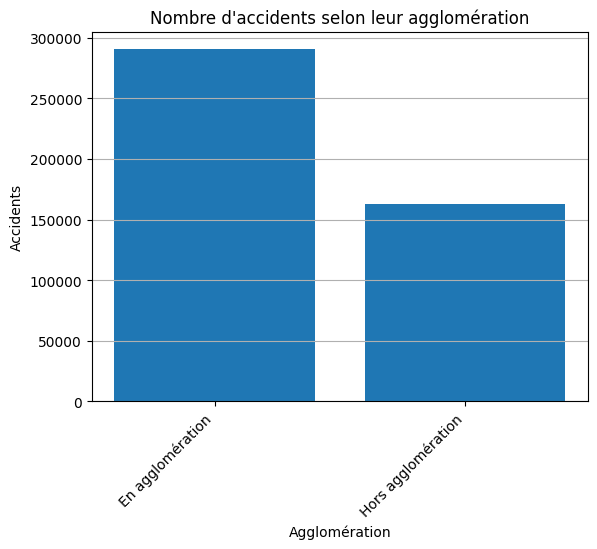

In [204]:
nb_accidents_par("agg", "Agglomération")

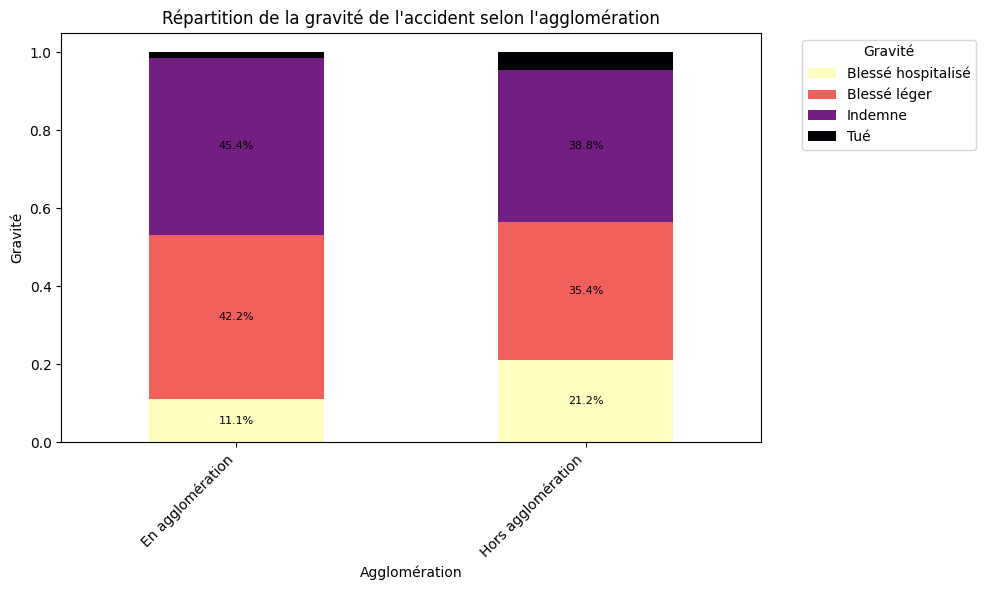

In [185]:

tc_agg_grav = pd.crosstab(df_final["agg"], df_final["grav"], normalize='index')
bar_chart(tc_agg_grav, "Agglomération", "Répartition de la gravité de l'accident selon l'agglomération")

### Conditions atmosphériques et météorologiques

#### Conditions d'éclairage

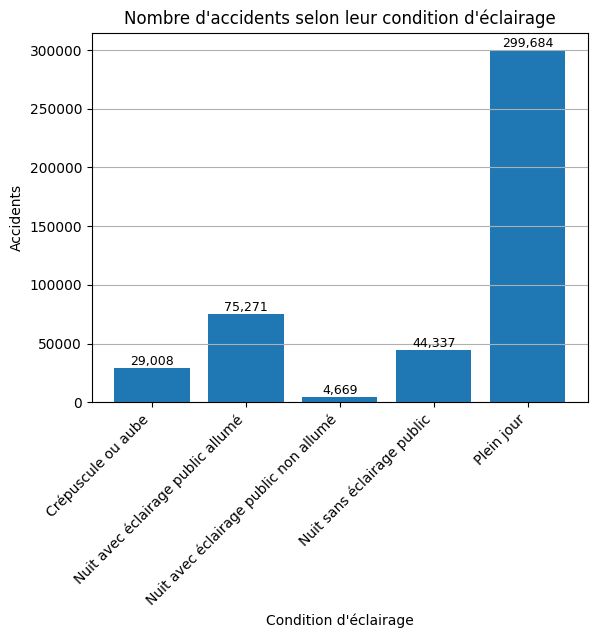

In [ ]:
nb_accidents_par("lum", "Condition d'éclairage", True)

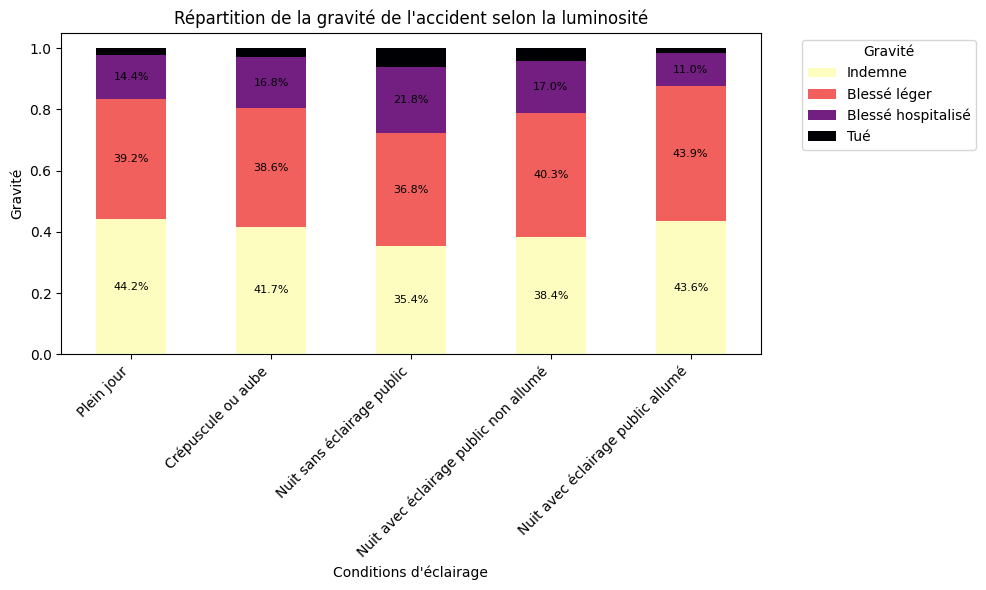

In [187]:
ordre_lignes  = [
    "Plein jour",
    "Crépuscule ou aube",
    "Nuit sans éclairage public",
    "Nuit avec éclairage public non allumé",
    "Nuit avec éclairage public allumé"
]

tc_lum_grav = pd.crosstab(df_final["lum"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)
bar_chart(tc_lum_grav, "Conditions d'éclairage", "Répartition de la gravité de l'accident selon la luminosité")

#### Conditions atmosphériques

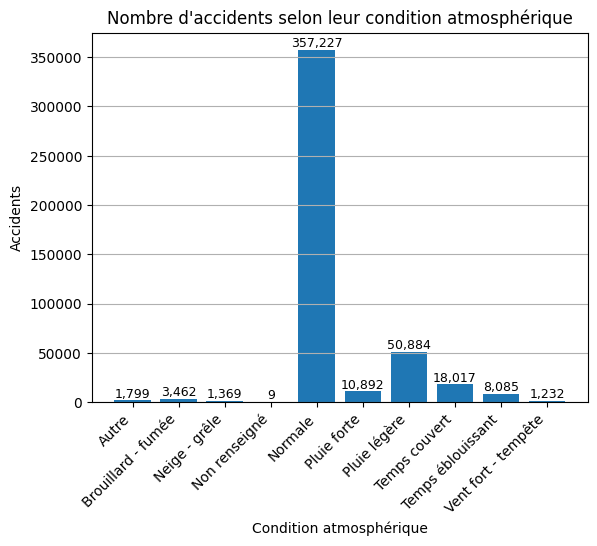

In [ ]:
nb_accidents_par("atm", "Condition atmosphérique", True)

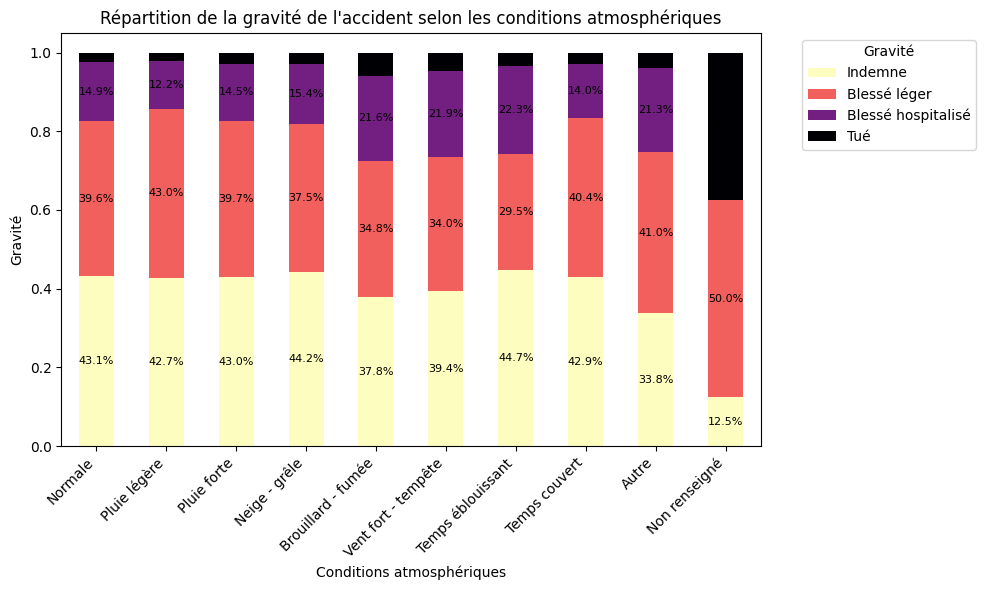

In [188]:
ordre_lignes  = [
    "Normale", 
    "Pluie légère", 
    "Pluie forte", 
    "Neige - grêle", 
    "Brouillard - fumée", 
    "Vent fort - tempête", 
    "Temps éblouissant", 
    "Temps couvert", 
    "Autre", 
    "Non renseigné"
]

tc_atm_grav = pd.crosstab(df_final["atm"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)


bar_chart(tc_atm_grav, "Conditions atmosphériques", "Répartition de la gravité de l'accident selon les conditions atmosphériques")

#### Conditions de la surface au sol

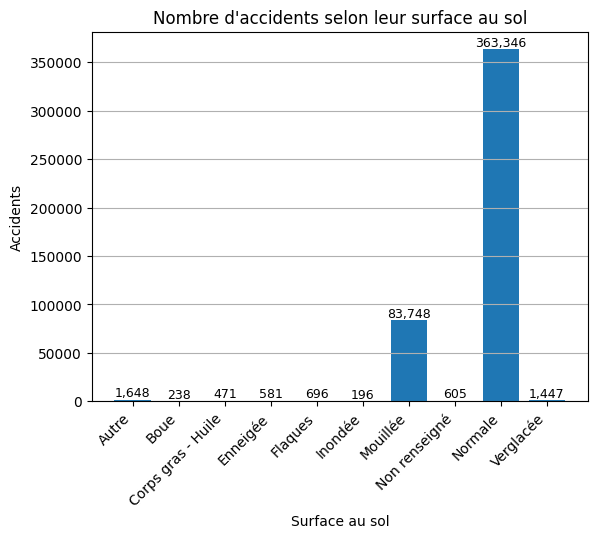

In [ ]:
nb_accidents_par("surf", "Surface au sol", True)

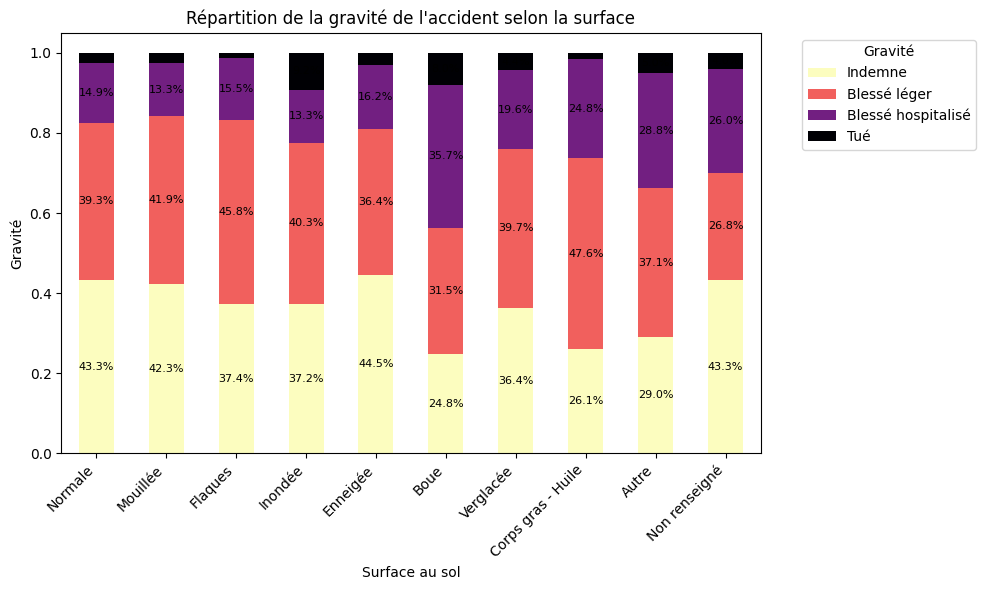

In [189]:
ordre_lignes = [
   "Normale",
   "Mouillée",
   "Flaques",
   "Inondée",
   "Enneigée",
   "Boue",
   "Verglacée",
   "Corps gras - Huile",
   "Autre",
   "Non renseigné"
]

tc_surf_grav = pd.crosstab(df_final["surf"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)
bar_chart(tc_surf_grav, "Surface au sol", "Répartition de la gravité de l'accident selon la surface")

La proportion de tués est plus grande lorsque les accidents ont lieu sur des surfaces inondées (9,2 %) ou boueuses (8,0 %) par rapport aux autres situations. La part de blessés hospitalisées est particulièrement importante dans ce second cas (35,7 %), alors qu'il n'excède pas 25 % quand la surface est spécifiée.